In [92]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

DATA_FOLD = Path.cwd().parent
DATA_DIR = DATA_FOLD / "data" / "processed" / "cleaned_delivery_data.csv"

df = pd.read_csv(DATA_DIR)
df.head()

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
0,0x4607,INDORES13DEL02,37.0,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,11:30:00,11:45:00,Sunny,High,2,Snack,motorcycle,0.0,No,Urban,24
1,0xb379,BANGRES18DEL02,34.0,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,19:45:00,19:50:00,Stormy,Jam,2,Snack,scooter,1.0,No,Metropolitian,33
2,0x5d6d,BANGRES19DEL01,23.0,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,08:30:00,08:45:00,Sandstorms,Low,0,Drinks,motorcycle,1.0,No,Urban,26
3,0x7a6a,COIMBRES13DEL02,38.0,4.7,11.003669,76.976494,11.053669,77.026494,05-04-2022,18:00:00,18:10:00,Sunny,Medium,0,Buffet,motorcycle,1.0,No,Metropolitian,21
4,0x70a2,CHENRES12DEL01,32.0,4.6,12.972793,80.249982,13.012793,80.289982,26-03-2022,13:30:00,13:45:00,Cloudy,High,1,Snack,scooter,1.0,No,Metropolitian,30


In [93]:
# Categorical columns: fill missing values with the mode (most frequent category)
for col in ['Weatherconditions','Road_traffic_density','Festival','City']:
  df[col].fillna(df[col].mode()[0],inplace=True)


# Numeric columns: fill missing values with the median (robust to outliers/skew)
for col in ['Delivery_person_Age','Delivery_person_Ratings','multiple_deliveries'] :
  df[col]=df[col].fillna(df[col].median())

C:\Users\Divya S. Shekhawat\AppData\Local\Temp\ipykernel_11108\1260140005.py:3: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df[col].fillna(df[col].mode()[0],inplace=True)


`Exploratory data analysis`

In [94]:
df['Time_taken(min)'].describe()

count    45593.000000
mean        26.294607
std          9.383806
min         10.000000
25%         19.000000
50%         26.000000
75%         32.000000
max         54.000000
Name: Time_taken(min), dtype: float64

<Axes: xlabel='Time_taken(min)', ylabel='Count'>

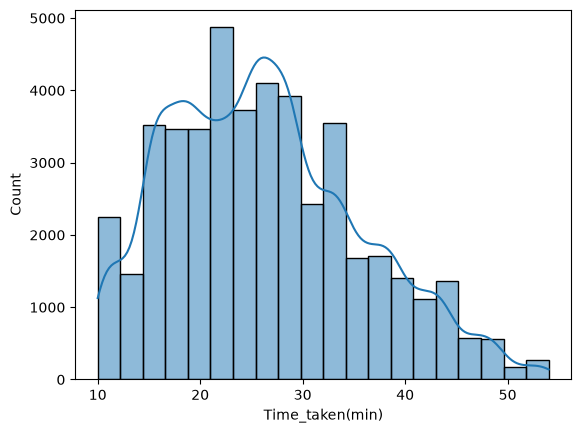

In [95]:
sns.histplot(df['Time_taken(min)'], bins= 20, kde = True)

In [96]:
# Weather vs delivery time
df.groupby('Weatherconditions')['Time_taken(min)'].agg(['count','mean','median','std'])

,count,mean,median,std
Weatherconditions,,,,
Cloudy,7536,28.917330,28.0,10.084352
Fog,8270,28.739541,28.0,10.100816
Sandstorms,7495,25.875517,26.0,8.618434
Stormy,7586,25.870815,26.0,8.473273
Sunny,7284,21.856947,20.0,8.327210
Windy,7422,26.118836,26.0,8.615702


In [97]:
df.groupby('Festival')['Time_taken(min)'].agg(['count','mean','median','std'])

,count,mean,median,std
Festival,,,,
No,44697,25.909256,25.0,9.052291
Yes,896,45.517857,45.0,4.001915


<Axes: xlabel='Delivery_person_Age', ylabel='Count'>

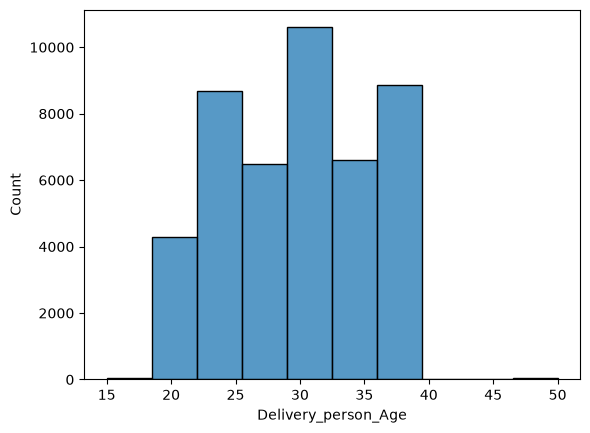

In [98]:

sns.histplot(df['Delivery_person_Age'],bins=10)

In [99]:

# How many riders are over 40? (checking the tail of the age distribution)
df[df['Delivery_person_Age']>40]['Delivery_person_Age'].shape

(53,)

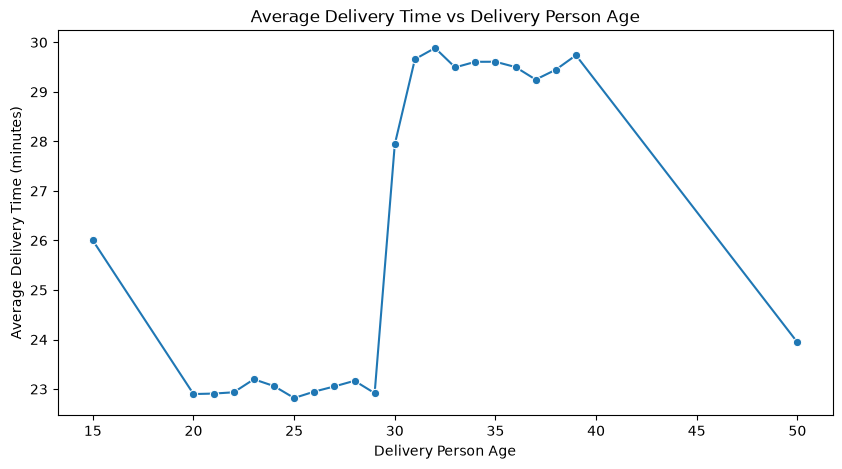

In [100]:

plt.figure(figsize=(10,5))

sns.lineplot(
    data=df,
    x="Delivery_person_Age",
    y="Time_taken(min)",
    estimator="mean",
    errorbar=None,
    marker="o"
)

plt.title("Average Delivery Time vs Delivery Person Age")
plt.xlabel("Delivery Person Age")
plt.ylabel("Average Delivery Time (minutes)")

plt.show()

In [101]:

df['Delivery_person_Ratings'].describe()

count    45593.000000
mean         4.636552
std          0.327906
min          1.000000
25%          4.600000
50%          4.700000
75%          4.800000
max          6.000000
Name: Delivery_person_Ratings, dtype: float64

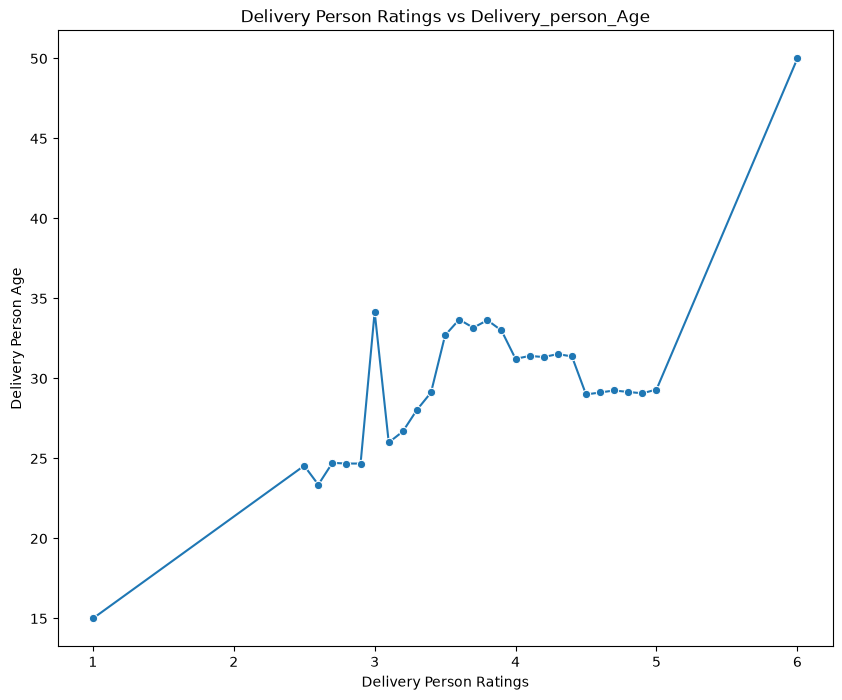

In [102]:
plt.figure(figsize=(10, 8))

sns.lineplot(
    data=df,
    x="Delivery_person_Ratings",
    y="Delivery_person_Age",
    estimator="mean",
    errorbar=None,
    marker="o"
)

plt.title("Delivery Person Ratings vs Delivery_person_Age")
plt.xlabel("Delivery Person Ratings")
plt.ylabel("Delivery Person Age")

plt.show()

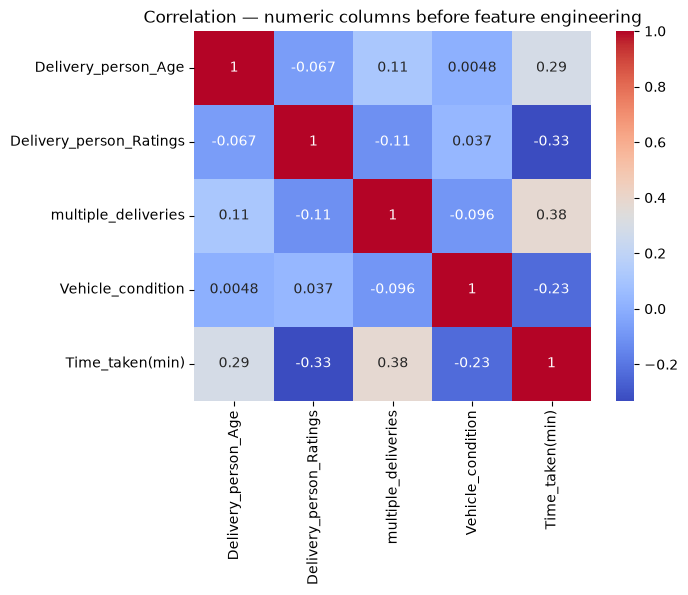

In [103]:

numeric_cols=['Delivery_person_Age','Delivery_person_Ratings','multiple_deliveries','Vehicle_condition','Time_taken(min)']
sns.heatmap(df[numeric_cols].corr(),annot=True,cmap='coolwarm')
plt.title('Correlation — numeric columns before feature engineering')
plt.show()
     

In [104]:
df['Vehicle_condition'].value_counts()

Vehicle_condition
2    15034
1    15030
0    15009
3      520
Name: count, dtype: int64

In [105]:
df['multiple_deliveries'].value_counts()

multiple_deliveries
1.0    29152
0.0    14095
2.0     1985
3.0      361
Name: count, dtype: int64

In [106]:

# Parse the time and pull out the hour; errors='coerce' turns unparseable times into NaT
hour=pd.to_datetime(df['Time_Orderd'],format='%H:%M:%S', errors='coerce').dt.hour

In [107]:
hour.unique()

array([11, 19,  8, 18, 13, 21, 17, 20, 14,  9, 22, 12, 23, 10, 16, 15,  0],
      dtype=int32)

In [108]:

# Does the hour of day relate to delivery time? (rush hours should stand out)
df.groupby(hour)['Time_taken(min)'].agg(['mean','median'])

,mean,median
Time_Orderd,,
0,22.169767,21.0
8,19.584158,19.0
9,19.543914,19.0
10,19.482170,19.0
11,26.380734,27.0
12,26.826233,27.0
13,27.538265,27.0
14,27.537295,27.0
15,23.194731,23.0


In [109]:

def calculate_series_distance(
    lat1_series, lon1_series, lat2_series, lon2_series, miles=False
):
    """Calculates the great-circle (straight-line) distance between two series of

    lat/lon points using the Haversine formula. Returns distance in km (or
    miles). Turns four raw coordinate columns into one meaningful 'distance'
    feature.
    """
    r = 3956 if miles else 6371
    lat1, lon1, lat2, lon2 = map(
        np.radians, [lat1_series, lon1_series, lat2_series, lon2_series]
    )
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    c = 2 * np.arcsin(np.sqrt(a))
    return c * r


In [110]:
df['distance_km']=calculate_series_distance(df['Restaurant_latitude'],df['Restaurant_longitude'],df['Delivery_location_latitude'],df['Delivery_location_longitude'])
     

In [111]:

df=df[df['distance_km']<100].reset_index(drop=True)

In [112]:

# Hour of day the order was placed (0-23) — kept continuous, not binned (see note below)
df['order_hour']=pd.to_datetime(df['Time_Orderd'],format='%H:%M:%S', errors='coerce').dt.hour

In [113]:

# A handful of unparseable timestamps become NaN hours — fill with the median hour
df['order_hour'].fillna(df['order_hour'].median(),inplace=True)

C:\Users\Divya S. Shekhawat\AppData\Local\Temp\ipykernel_11108\822087219.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['order_hour'].fillna(df['order_hour'].median(),inplace=True)


0        11
1        19
2         8
3        18
4        13
         ..
45157    11
45158    19
45159    23
45160    13
45161    17
Name: order_hour, Length: 45162, dtype: int32

In [114]:
features=['Delivery_person_Age','Delivery_person_Ratings','distance_km','order_hour','Weatherconditions','Road_traffic_density',
          'Vehicle_condition','Type_of_order','Type_of_vehicle','multiple_deliveries','Festival','City']
     

In [115]:
df['Weatherconditions'].value_counts()

Weatherconditions
Fog           8071
Stormy        7544
Cloudy        7485
Sandstorms    7442
Windy         7382
Sunny         7238
Name: count, dtype: int64

In [116]:

X=df[features]

y=df['Time_taken(min)']

In [117]:
X.isnull().sum()

Delivery_person_Age        0
Delivery_person_Ratings    0
distance_km                0
order_hour                 0
Weatherconditions          0
Road_traffic_density       0
Vehicle_condition          0
Type_of_order              0
Type_of_vehicle            0
multiple_deliveries        0
Festival                   0
City                       0
dtype: int64

In [118]:
X = pd.get_dummies(
    X,
    columns=[
        'Type_of_order',
        'Type_of_vehicle',
        'Festival',
        'City',
        'Weatherconditions'
    ],
    drop_first=True,
    dtype=int
)

In [119]:

# Traffic density has a real order (Low < Medium < High < Jam) -> ordinal encode instead of one-hot,
# so the model can learn a single, sensible increasing relationship
traffic_mapping={
    'Low':0,
    'Medium': 1,
    'High' : 2,
    'Jam' : 3
}

X['Road_traffic_density']=X['Road_traffic_density'].map(traffic_mapping)

In [120]:

from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)


from sklearn.preprocessing import StandardScaler
scaler= StandardScaler()

In [121]:
df

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,...,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min),distance_km,order_hour
0,0x4607,INDORES13DEL02,37.0,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,11:30:00,...,High,2,Snack,motorcycle,0.0,No,Urban,24,3.025149,11
1,0xb379,BANGRES18DEL02,34.0,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,19:45:00,...,Jam,2,Snack,scooter,1.0,No,Metropolitian,33,20.183530,19
2,0x5d6d,BANGRES19DEL01,23.0,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,08:30:00,...,Low,0,Drinks,motorcycle,1.0,No,Urban,26,1.552758,8
3,0x7a6a,COIMBRES13DEL02,38.0,4.7,11.003669,76.976494,11.053669,77.026494,05-04-2022,18:00:00,...,Medium,0,Buffet,motorcycle,1.0,No,Metropolitian,21,7.790401,18
4,0x70a2,CHENRES12DEL01,32.0,4.6,12.972793,80.249982,13.012793,80.289982,26-03-2022,13:30:00,...,High,1,Snack,scooter,1.0,No,Metropolitian,30,6.210138,13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45157,0x7c09,JAPRES04DEL01,30.0,4.8,26.902328,75.794257,26.912328,75.804257,24-03-2022,11:35:00,...,High,1,Meal,motorcycle,0.0,No,Metropolitian,32,1.489846,11
45158,0xd641,AGRRES16DEL01,21.0,4.6,0.000000,0.000000,0.070000,0.070000,16-02-2022,19:55:00,...,Jam,0,Buffet,motorcycle,1.0,No,Metropolitian,36,11.007735,19
45159,0x4f8d,CHENRES08DEL03,30.0,4.9,13.022394,80.242439,13.052394,80.272439,11-03-2022,23:50:00,...,Low,1,Drinks,scooter,0.0,No,Metropolitian,16,4.657195,23
45160,0x5eee,COIMBRES11DEL01,20.0,4.7,11.001753,76.986241,11.041753,77.026241,07-03-2022,13:35:00,...,High,0,Snack,motorcycle,1.0,No,Metropolitian,26,6.232393,13


In [122]:

# Fit the scaler on TRAIN ONLY, then apply it to both — never fit on test data
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [123]:
from pathlib import Path
import joblib

MODEL_FOLDER = Path.cwd().parent

ARTIFACTS_FOLDER = MODEL_FOLDER / "artifacts"
ARTIFACTS_FOLDER.mkdir(parents=True, exist_ok=True)

# SAVE_MODEL = ARTIFACTS_FOLDER / "model.pkl"
SAVE_SCALER = ARTIFACTS_FOLDER / "standard_scaler.pkl"

# joblib.dump(model, SAVE_MODEL)
joblib.dump(scaler, SAVE_SCALER)

# print(f"Model saved at: {SAVE_MODEL}")
print(f"Scaler saved at: {SAVE_SCALER}")

Scaler saved at: c:\Users\Divya S. Shekhawat\Downloads\CODING\Machine Learning Projects and practices\ML-projects\delivery-time-prediction\artifacts\standard_scaler.pkl


In [124]:

from sklearn.linear_model import LinearRegression

lr=LinearRegression()
lr.fit(X_train_scaled,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](21,)","[ 2.28,-2.17, 2.07,...,-1.01,-2.31,-0.97]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,26.28
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,21
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(21)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](21,)","[293.29,258.43,220.12,...,109.27, 84.67, 8.8 ]"


In [125]:

from sklearn.metrics import r2_score,mean_squared_error

     

# Predictions on the held-out test set
y_pred_test=lr.predict(X_test_scaled)
     

# Test RMSE (average error in minutes)
rmse_test=np.sqrt(mean_squared_error(y_test,y_pred_test))
     

# Train RMSE — compare with test RMSE to check for overfitting
rmse_train=np.sqrt(mean_squared_error(y_train,lr.predict(X_train_scaled)))
     

r2_test=r2_score(y_test,y_pred_test)
     

r2_train=r2_score(y_train,lr.predict(X_train_scaled))
     

# Train: RMSE, R²
print(rmse_train,r2_train)

# Test: RMSE, R²  — close to train, so the linear model underfits rather than overfits
print(rmse_test,r2_test)

6.04607676669889 0.5829917971160234
6.215030826811804 0.5689660140358084


In [126]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error
     

dt=DecisionTreeRegressor(random_state=42)
     

dt.fit(X_train_scaled,y_train)
     
DecisionTreeRegressor(random_state=42)

y_pred_dt=dt.predict(X_test_scaled)
     

# Test performance

mse=mean_squared_error(y_test,dt.predict(X_test_scaled))
rmse=np.sqrt(mse)
r2=r2_score(y_test,dt.predict(X_test_scaled))
print("dt rmse",rmse)
print("dt r2",r2)
     

# Now check TRAIN performance for comparison — this is how we catch overfitting

mse=mean_squared_error(y_train,dt.predict(X_train_scaled))
rmse=np.sqrt(mse)
r2=r2_score(y_train,dt.predict(X_train_scaled))
print("dt train rmse",rmse)
print("dt train r2",r2)

dt rmse 5.473960378278258
dt r2 0.6656292806718312
dt train rmse 0.0
dt train r2 1.0


In [127]:
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error
from sklearn.ensemble import RandomForestRegressor
     

rf=RandomForestRegressor(n_estimators=100,random_state=42)
     

rf.fit(X_train_scaled,y_train)
     
RandomForestRegressor(random_state=42)


mse=mean_squared_error(y_test,rf.predict(X_test_scaled))
rmse=np.sqrt(mse)
r2=r2_score(y_test,rf.predict(X_test_scaled))
print("rf rmse",rmse)
print("rf r2",r2)

#train data
mse=mean_squared_error(y_train,rf.predict(X_train_scaled))
rmse=np.sqrt(mse)
r2=r2_score(y_train,rf.predict(X_train_scaled))
print("rf rmse",rmse)
print("rf r2",r2)

rf rmse 4.0273836842542154
rf r2 0.819003176526223
rf rmse 1.506611994936138
rf r2 0.9741059414709188


Best Parameters:
{'n_estimators': 400, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 0.5, 'max_depth': 20}

Best CV R²:
0.8231154601650683

MODEL PERFORMANCE
R² Score : 0.8297892589812341
RMSE     : 3.9055392885962665

Actual vs Predicted:
    Actual  Predicted     Error
0       46  40.676841  5.323159
1       19  17.434413  1.565587
2       40  37.163855  2.836145
3       36  39.002016 -3.002016
4       33  34.421969 -1.421969
5       38  35.114527  2.885473
6       32  31.995415  0.004585
7       19  12.634342  6.365658
8       34  36.863033 -2.863033
9       16  16.945477 -0.945477
10      32  35.741254 -3.741254
11      24  24.634290 -0.634290
12      32  32.622695 -0.622695
13      26  20.558562  5.441438
14      27  25.261597  1.738403
15      26  25.296238  0.703762
16      29  22.693672  6.306328
17      40  39.493371  0.506629
18      22  18.380258  3.619742
19      28  28.590793 -0.590793


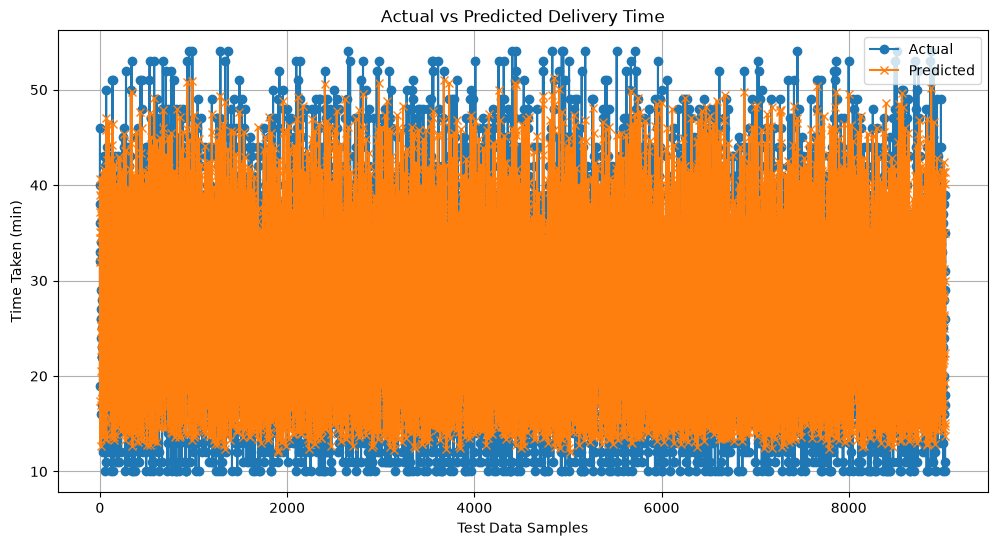

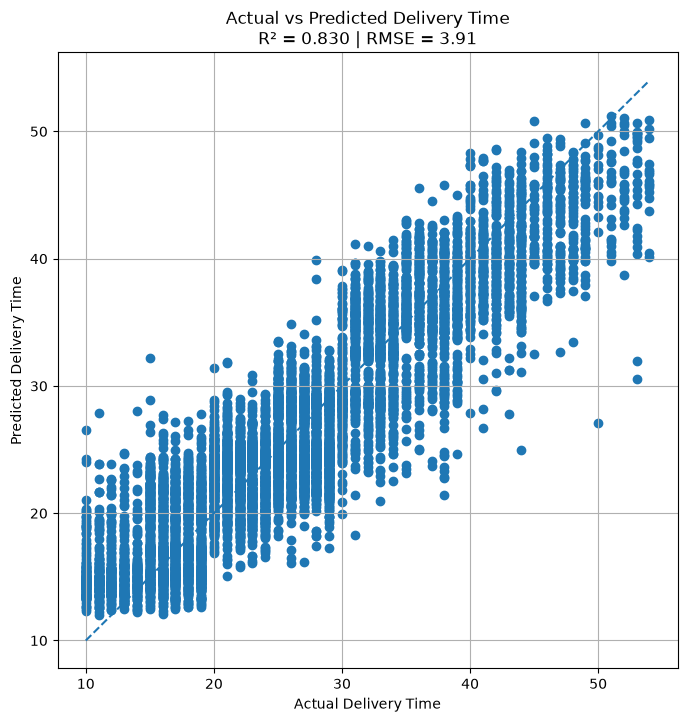


Feature Importance:
                             Feature  Importance
1            Delivery_person_Ratings    0.193294
4               Road_traffic_density    0.143668
2                        distance_km    0.118207
6                multiple_deliveries    0.107378
0                Delivery_person_Age    0.105314
5                  Vehicle_condition    0.079440
19           Weatherconditions_Sunny    0.074356
16             Weatherconditions_Fog    0.030697
3                         order_hour    0.029683
17      Weatherconditions_Sandstorms    0.024601
20           Weatherconditions_Windy    0.023423
18          Weatherconditions_Stormy    0.022740
13                      Festival_Yes    0.020881
15                        City_Urban    0.006117
11        Type_of_vehicle_motorcycle    0.003889
8                 Type_of_order_Meal    0.003355
9                Type_of_order_Snack    0.003236
7               Type_of_order_Drinks    0.003223
14                   City_Semi-Urban    0.002864

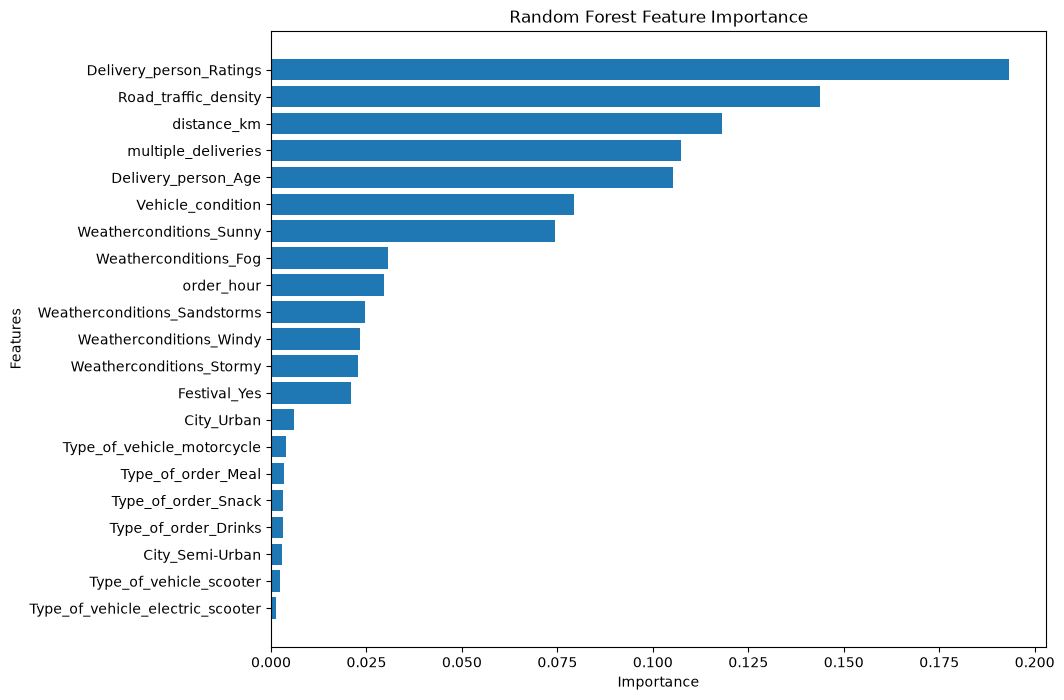

In [130]:
# ============================================
# 1. IMPORT LIBRARIES
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import r2_score, mean_squared_error


# ============================================
# 2. RANDOM FOREST HYPERPARAMETER DISTRIBUTION
# ============================================

rf_param_dist = {
    'n_estimators': [200, 300, 400, 500],
    'max_depth': [10, 15, 20, 25, None],
    'min_samples_leaf': [1, 2, 4],
    'min_samples_split': [2, 5, 10],
    'max_features': ['sqrt', 'log2', 0.5]
}


# ============================================
# 3. RANDOMIZED SEARCH
# ============================================

rf_search = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42),

    param_distributions=rf_param_dist,

    # Try 25 random combinations
    n_iter=25,

    # 3-fold cross validation
    cv=3,

    # Regression evaluation metric
    scoring='r2',

    random_state=42,

    # Use all CPU cores
    n_jobs=-1
)


# ============================================
# 4. TRAIN MODEL
# ============================================

rf_search.fit(X_train_scaled, y_train)


# ============================================
# 5. BEST PARAMETERS
# ============================================

print("Best Parameters:")
print(rf_search.best_params_)

print("\nBest CV R²:")
print(rf_search.best_score_)


# ============================================
# 6. GET BEST MODEL
# ============================================

rf_best = rf_search.best_estimator_


# ============================================
# 7. PREDICTION
# ============================================

y_pred = rf_best.predict(X_test_scaled)


# ============================================
# 8. MODEL EVALUATION
# ============================================

r2_rf_tuned = r2_score(y_test, y_pred)

rmse_rf_tuned = np.sqrt(
    mean_squared_error(y_test, y_pred)
)


print("\n==============================")
print("MODEL PERFORMANCE")
print("==============================")

print("R² Score :", r2_rf_tuned)
print("RMSE     :", rmse_rf_tuned)


# ============================================
# 9. ACTUAL VS PREDICTED TABLE
# ============================================

results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

results["Error"] = results["Actual"] - results["Predicted"]

print("\nActual vs Predicted:")
print(results.head(20))


# ============================================
# 10. ACTUAL VS PREDICTED LINE PLOT
# ============================================

plt.figure(figsize=(12, 6))

plt.plot(
    y_test.values,
    label="Actual",
    marker="o"
)

plt.plot(
    y_pred,
    label="Predicted",
    marker="x"
)

plt.title("Actual vs Predicted Delivery Time")

plt.xlabel("Test Data Samples")

plt.ylabel("Time Taken (min)")

plt.legend()

plt.grid(True)

plt.show()


# ============================================
# 11. ACTUAL VS PREDICTED SCATTER PLOT
# ============================================

plt.figure(figsize=(8, 8))

plt.scatter(
    y_test,
    y_pred
)

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual Delivery Time")

plt.ylabel("Predicted Delivery Time")

plt.title(
    f"Actual vs Predicted Delivery Time\n"
    f"R² = {r2_rf_tuned:.3f} | RMSE = {rmse_rf_tuned:.2f}"
)

plt.grid(True)

plt.show()


# ============================================
# 12. FEATURE IMPORTANCE
# ============================================

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_best.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("\nFeature Importance:")
print(feature_importance)


# ============================================
# 13. FEATURE IMPORTANCE PLOT
# ============================================

plt.figure(figsize=(10, 8))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance")

plt.ylabel("Features")

plt.title("Random Forest Feature Importance")

plt.gca().invert_yaxis()

plt.show()

In [129]:
SAVE_MODEL = ARTIFACTS_FOLDER / "xgb_best.pkl"
joblib.dump(SAVE_MODEL, "xgb_best.pkl")

['xgb_best.pkl']